# 26_model_distribution_JIW

- 목적: 정상 윈도우의 분포를 학습해 분포에서 먼 정도를 이상점수로 쓰는 모델을 같은 계약으로 비교하고, 착수 가이드 §7의 피처군 ablation(기본·+사인·+형상·+관계)을 보고한다.
- 입력: `data/raw`(없으면 zip 자동 추출) → `preprocess.preprocess()`, `data/processed/11_window_features.parquet`(윈도우 목록·분할·state)
- 출력: `figures/26_model_distribution_JIW/`, `results/26_model_distribution_JIW/`(metrics.csv · cv_scores.csv · error_cases.csv), `models/26_model_distribution_JIW/`(가중치, git 제외)
- 담당: JIW
- 탐지 대상: 모터-펌프 구동부 이상 (가이드북은 센서를 "유압펌프 상/하단"에 설치했다고 쓰지만 유압 유닛이 모터-펌프 일체형이라 진동 센서의 정확한 부착 부위를 알 수 없어 펌프/모터 원인을 구분할 수 없음, 착수 가이드 머리말)
- 심사 대응: 2번(모델 비교), 3번(FP 운전 상태·FN 세그먼트), 5번(합성 이상 주입 평가), 6번(재현성: 가중치 재사용·시드 고정)

파일명 규칙: 0x 진단 · 1x 전처리·피처 · 2x 모델 · 3x 분석

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "26_model_distribution_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B

KEYS = ['mcd', 'ocsvm', 'hbos', 'copod', 'deep_svdd']
WIN_LIST = (1.0, 2.0)      # 착수 가이드 §2: 1~3초. 21 smoke(1초)와 지연 비교용 1초 + 사전 비교 기준 2초
SEEDS = (0, 1, 2)
EPOCHS = 30
LOOKBACK = 5               # 0.5초
RETRAIN = False            # models/26_model_distribution_JIW/ 가중치가 있으면 불러와 평가만 한다
FEATURE_SETS = B.FEATURE_SETS  # 피처 모델 입력 조합 (착수 가이드 §7)
PROGRESS = False           # 터미널 실행 시 True면 tqdm 진행 막대 표시
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

26_model_distribution_JIW figures\26_model_distribution_JIW results\26_model_distribution_JIW


## 1. 모델

| 모델 | 입력 | 이상점수 |
|---|---|---|
| MCD | 윈도우 피처 (조합별) | 강건 공분산(Minimum Covariance Determinant) Mahalanobis 거리 |
| OCSVM | 윈도우 피처 | RBF One-Class SVM 결정함수 (nu 0.05) |
| HBOS | 윈도우 피처 | 피처별 히스토그램 밀도 합 (피처 간 독립 가정) |
| COPOD | 윈도우 피처 | 경험적 copula 꼬리 확률 (피처 간 독립 가정) |
| DeepSVDD | 전처리 원신호 윈도우 (win × 3) | 1D-CNN 잠재공간 중심까지 거리 |

- 계열 근거: KDD'25 서베이 Density-based → Distribution. TSB-AD 다변량 VUS-PR MCD 0.27(계열 1위) · OCSVM 0.26 · COPOD 0.20 · HBOS 0.19.
- 피처 조합(착수 가이드 §7): `amp` = 진폭 18열(기본), `amp_sine` = +전류 사인 잔차 3열(세그먼트 수준 값, 날짜 교란 가능성 → 기본과 분리해 해석), `amp_shape` = +형상 9열, `amp_rel` = +채널 관계 3열(`vib_corr01`·`cur_ac1`·`vib_rms_ratio`).
- 결측(평탄 윈도우의 kurt·skew, 사인 피팅 실패)은 train 중앙값으로 채운다.
- OCSVM은 22 노트북 후보(IsolationForest/OC-SVM)와 겹치므로 22 결과가 나오면 비교표에서 하나만 대표로 쓴다.

평가 계약(`docs/modeling_kickoff.md`): 입력 = 표준 전처리 결과, 분할 = `group_kfold_seg`(fold 0~4) · `time_block`(k=1~4), 임계 = train 정상 점수 q99, 지표 = `evaluate` 공통 함수. 학습은 정상 윈도우가 속한 세그먼트만 쓴다.

In [2]:
segs, W = B.load_inputs()
cov = W.groupby(["win_s", "label"]).size().unstack().rename(columns={0: "정상 윈도우", 1: "이상 윈도우"})
cov["이상 세그먼트(윈도우 있음)"] = W[W.label == 1].groupby("win_s")["seg_uid"].nunique()
print("세그먼트", len(segs)); cov.loc[list(WIN_LIST)]

세그먼트 620


label,정상 윈도우,이상 윈도우,이상 세그먼트(윈도우 있음)
win_s,,,
1.0,3264,96,17
2.0,2254,63,13


## 2. 학습·평가 (윈도우 × 분할 × 시드)

판정 불가(세그먼트 길이 < 윈도우) 이상 세그먼트 비율은 1초 19.05%, 2초 38.10%다(착수 가이드 §2).

In [3]:
cv, err, sc = B.run(KEYS, NB, win_list=WIN_LIST, seeds=SEEDS, epochs=EPOCHS, lookback=LOOKBACK,
                    retrain=RETRAIN, progress=PROGRESS, segs=segs, W=W, feature_sets=FEATURE_SETS)
metrics = B.to_metrics(cv)
metrics.to_csv(RES / "metrics.csv", index=False)
cv.to_csv(RES / "cv_scores.csv", index=False)
err.to_csv(RES / "error_cases.csv", index=False)
print(cv["status"].value_counts().to_dict(), "runs", len(cv))
metrics[metrics["fold"] == "mean"].round(4)

{'loaded': 342} runs 342


,model,split,fold,auc,fpr_sample,fpr_segment,delay_median_s,win_s,thr,n_out_seg,n_detected,felt_delay_median_s
306,mcd_amp_w1s,group_kfold_seg,mean,0.9842,0.0092,0.0451,0.9,1.0,518.7841,3.4,3.4000,8.858
307,mcd_amp_sine_w1s,group_kfold_seg,mean,1.0000,0.0104,0.0546,0.9,1.0,716.8285,3.4,3.4000,8.858
308,mcd_amp_shape_w1s,group_kfold_seg,mean,0.9982,0.0113,0.0489,0.9,1.0,178.0446,3.4,3.4000,8.858
309,mcd_amp_rel_w1s,group_kfold_seg,mean,0.9940,0.0110,0.0506,0.9,1.0,647.0850,3.4,3.4000,8.858
310,ocsvm_amp_w1s,group_kfold_seg,mean,0.9951,0.0142,0.0726,0.9,1.0,2.0194,3.4,3.4000,8.858
...,...,...,...,...,...,...,...,...,...,...,...,...
369,copod_amp_w2s,time_block,mean,0.9903,0.0023,0.0086,1.9,2.0,42.4764,13.0,13.0000,9.858
370,copod_amp_sine_w2s,time_block,mean,0.9992,0.0047,0.0115,1.9,2.0,46.2031,13.0,13.0000,9.858
371,copod_amp_shape_w2s,time_block,mean,0.9971,0.0029,0.0142,1.9,2.0,59.6268,13.0,13.0000,9.858
372,copod_amp_rel_w2s,time_block,mean,0.9988,0.0012,0.0057,1.9,2.0,46.0715,13.0,13.0000,9.858


## 3. 요약 (fold·시드 평균)

`fpr_high_load`·`fpr_low_load`는 정상 윈도우의 운전 상태별 오경보율(state 0 = 고부하, 1 = 저부하), `inj_mean`은 합성 이상 탐지율(4유형 × 강도 0.25·0.5·1·2 평균).

In [4]:
B.summary(cv)

,,,auc,fpr_sample,fpr_segment,recall_window,n_detected,n_out_seg,delay_median_s,fpr_high_load,fpr_low_load,inj_mean
model,win_s,split,,,,,,,,,,
MCD [amp],1.0,group_kfold_seg,0.984,0.009,0.045,0.875,3.400,3.4,0.9,0.019,0.002,0.087
MCD [amp_sine],1.0,group_kfold_seg,1.000,0.010,0.055,1.000,3.400,3.4,0.9,0.017,0.005,0.223
MCD [amp_shape],1.0,group_kfold_seg,0.998,0.011,0.049,0.944,3.400,3.4,0.9,0.012,0.010,0.102
MCD [amp_rel],1.0,group_kfold_seg,0.994,0.011,0.051,0.949,3.400,3.4,0.9,0.021,0.003,0.094
OCSVM [amp],1.0,group_kfold_seg,0.995,0.014,0.073,0.946,3.400,3.4,0.9,0.011,0.016,0.153
...,...,...,...,...,...,...,...,...,...,...,...,...
COPOD [amp],2.0,time_block,0.990,0.002,0.009,0.702,13.000,13.0,1.9,0.005,0.000,0.067
COPOD [amp_sine],2.0,time_block,0.999,0.005,0.011,0.956,13.000,13.0,1.9,0.010,0.000,0.079
COPOD [amp_shape],2.0,time_block,0.997,0.003,0.014,0.865,13.000,13.0,1.9,0.005,0.001,0.067


21 규칙 베이스라인(`results/21_model_rule_baseline_CHS/metrics.csv`)과 같은 윈도우·분할의 fold 평균 비교. rule1 = AI0 RMS 크기, rule3 = 상태별 RMS × 방향(21의 최강 규칙).

In [5]:
cols = ["model", "win_s", "split", "auc", "fpr_sample", "fpr_segment", "delay_median_s", "n_detected", "n_out_seg"]
ref = B.baseline_table()
ref = ref[ref["model"].isin(B.BASELINE_RULES) & ref["win_s"].isin(WIN_LIST)][cols]
mine = metrics[metrics["fold"] == "mean"][cols]
pd.concat([ref, mine]).sort_values(["win_s", "split", "auc"], ascending=[True, True, False]).round(4).reset_index(drop=True)

,model,win_s,split,auc,fpr_sample,fpr_segment,delay_median_s,n_detected,n_out_seg
0,mcd_amp_sine_w1s,1.0,group_kfold_seg,1.0000,0.0104,0.0546,0.9,3.4000,3.4
1,ocsvm_amp_sine_w1s,1.0,group_kfold_seg,1.0000,0.0172,0.0896,0.9,3.4000,3.4
2,ocsvm_amp_rel_w1s,1.0,group_kfold_seg,0.9999,0.0198,0.1106,0.9,3.4000,3.4
3,mcd_amp_shape_w1s,1.0,group_kfold_seg,0.9982,0.0113,0.0489,0.9,3.4000,3.4
4,copod_amp_sine_w1s,1.0,group_kfold_seg,0.9980,0.0058,0.0264,0.9,3.4000,3.4
...,...,...,...,...,...,...,...,...,...
71,copod_amp_w2s,2.0,time_block,0.9903,0.0023,0.0086,1.9,13.0000,13.0
72,hbos_amp_w2s,2.0,time_block,0.9903,0.0122,0.0399,1.9,13.0000,13.0
73,deep_svdd_w2s,2.0,time_block,0.9582,0.0557,0.1783,1.9,12.9167,13.0
74,rule3_rms_state_dir,2.0,time_block,0.9196,0.0056,0.0082,1.9,12.0000,13.0


## 4. 그림

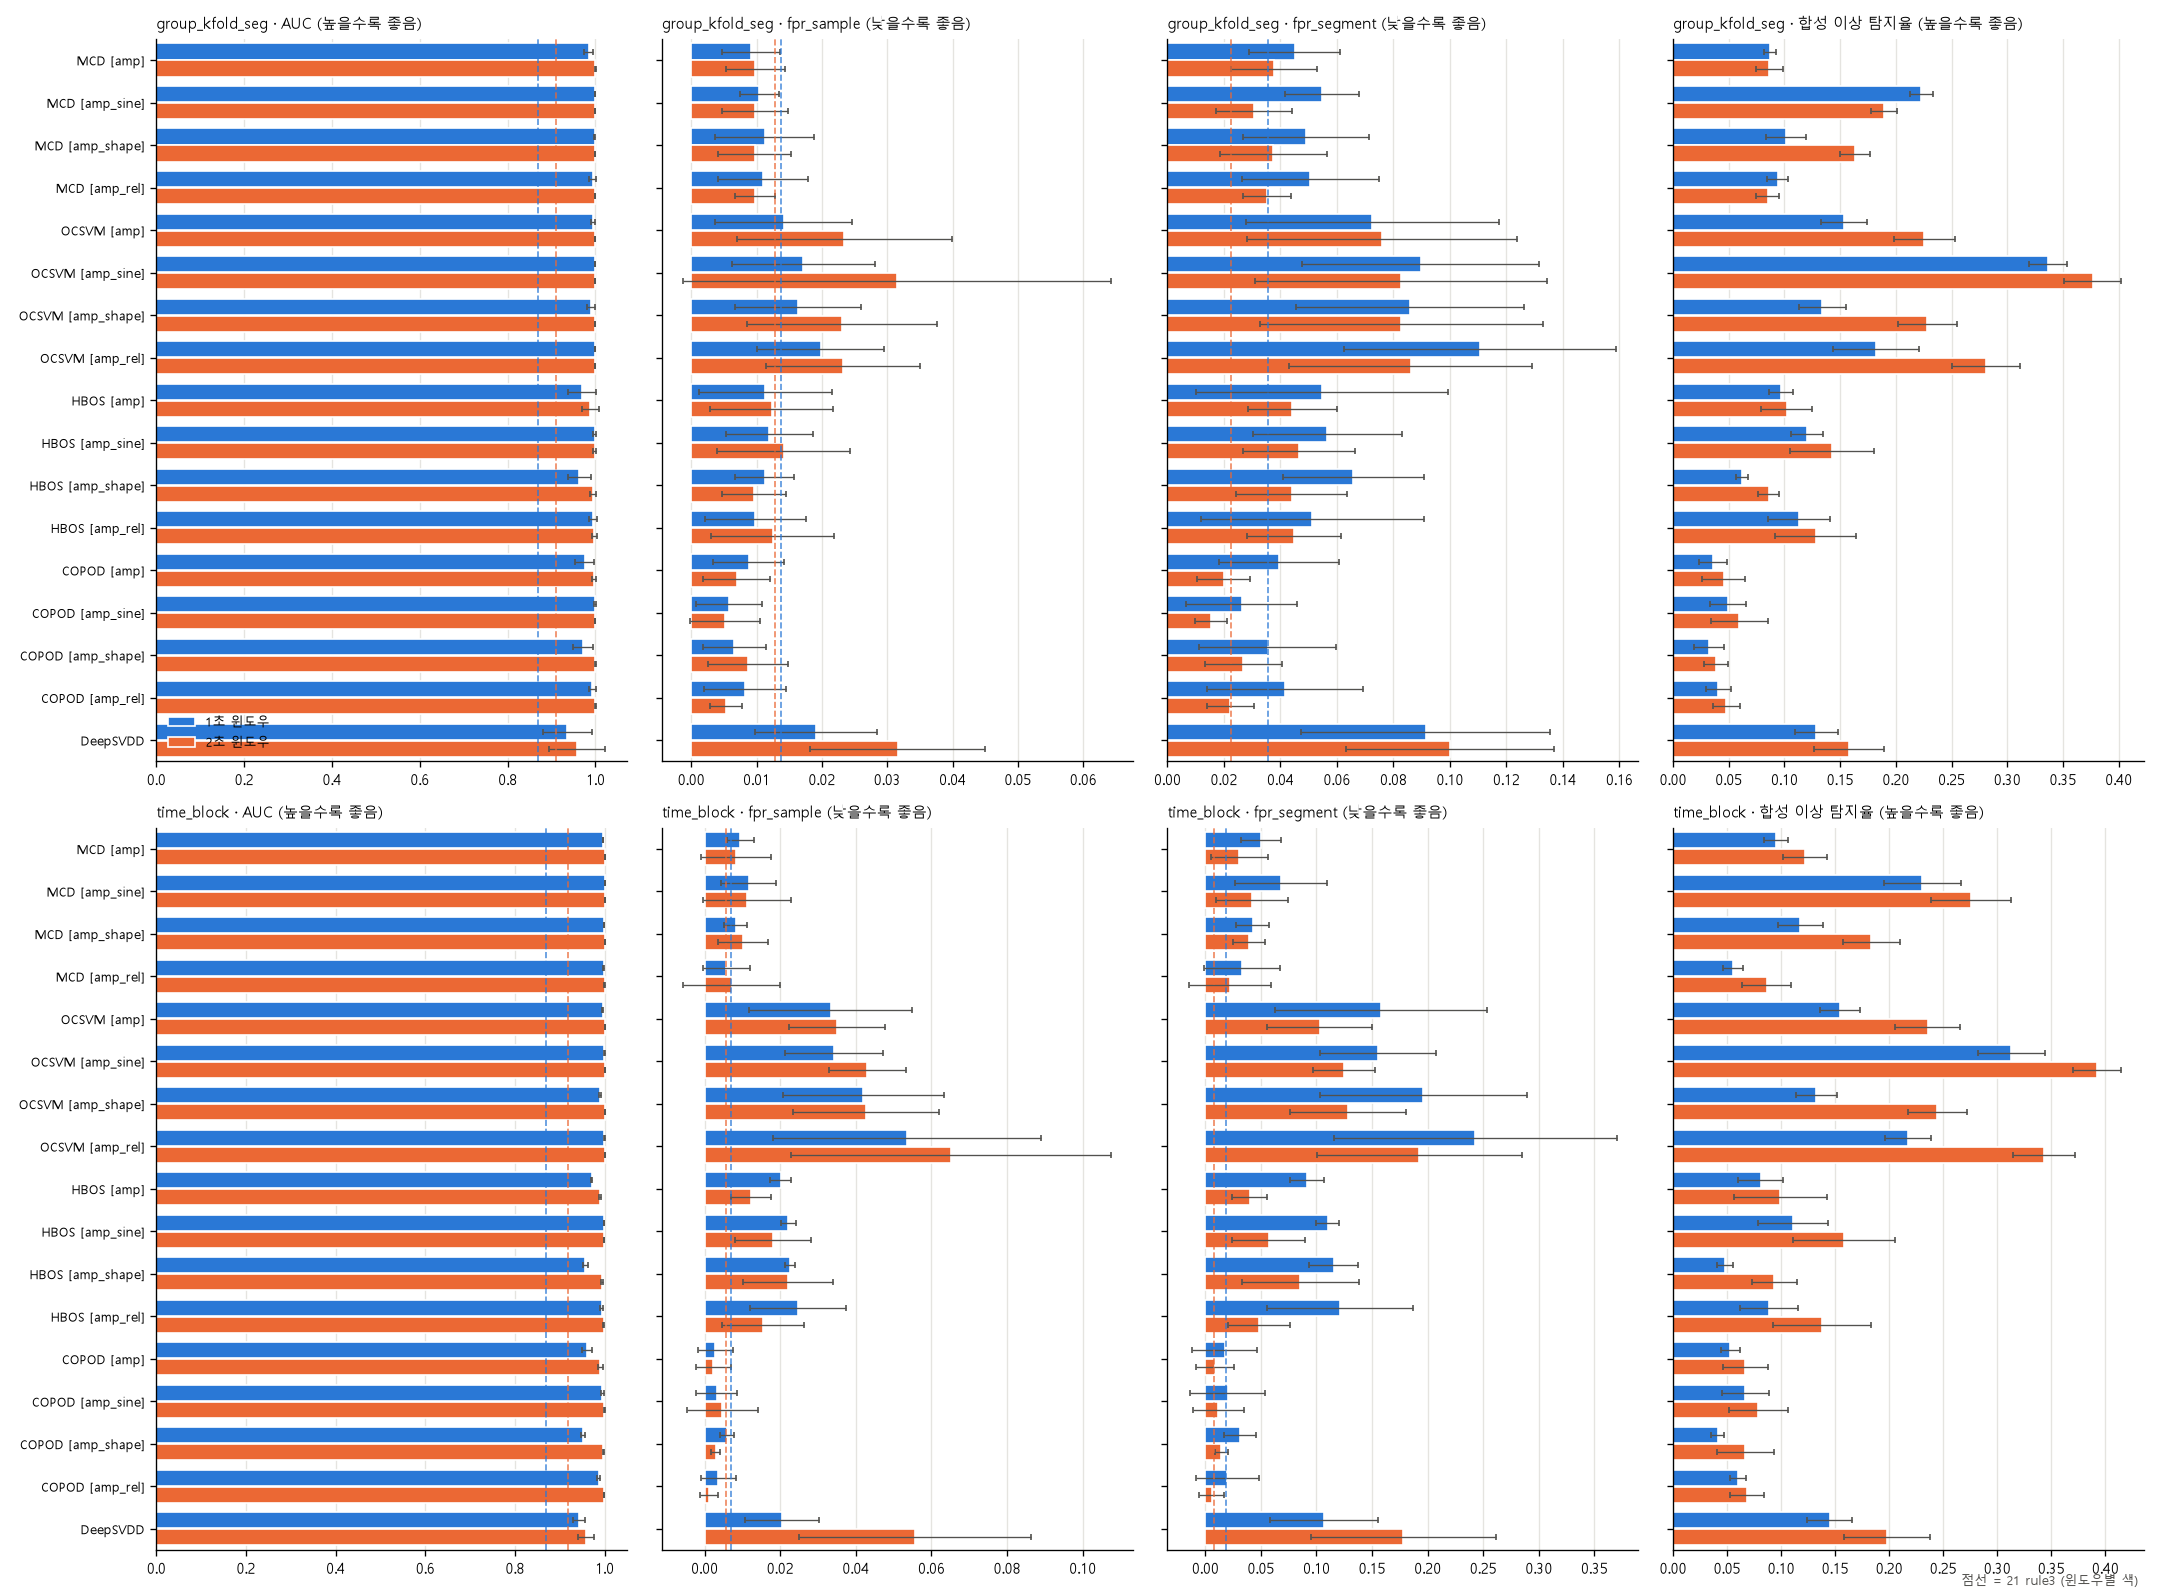

In [6]:
B.plot_overview(cv, FIG); display(Image(FIG / "metrics_overview.png"))

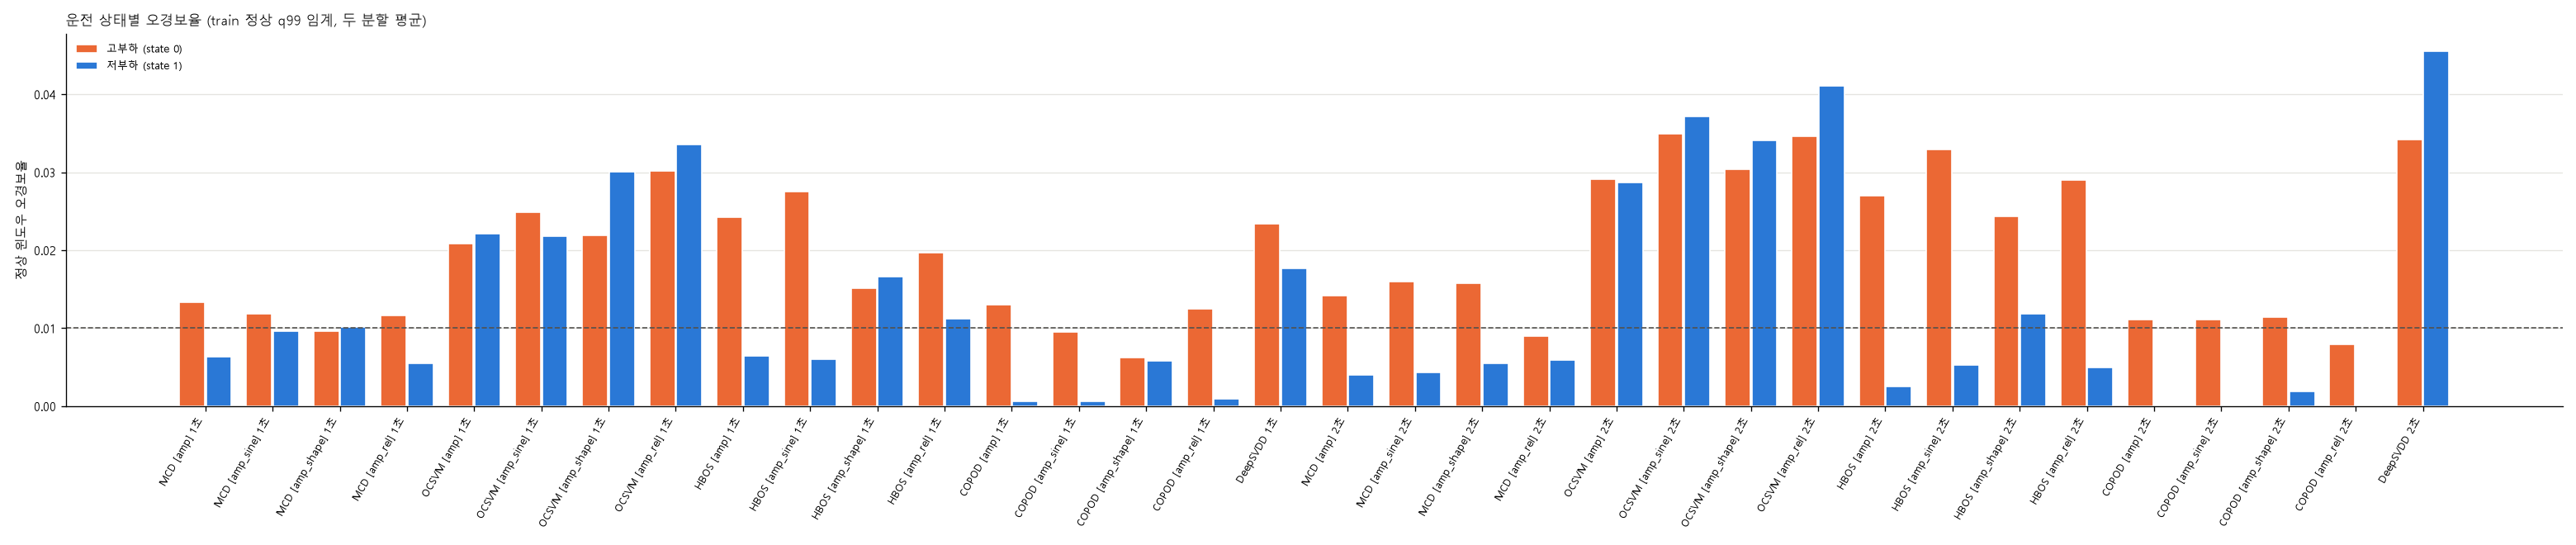

In [7]:
B.plot_state_fpr(cv, FIG); display(Image(FIG / "fpr_by_state.png"))

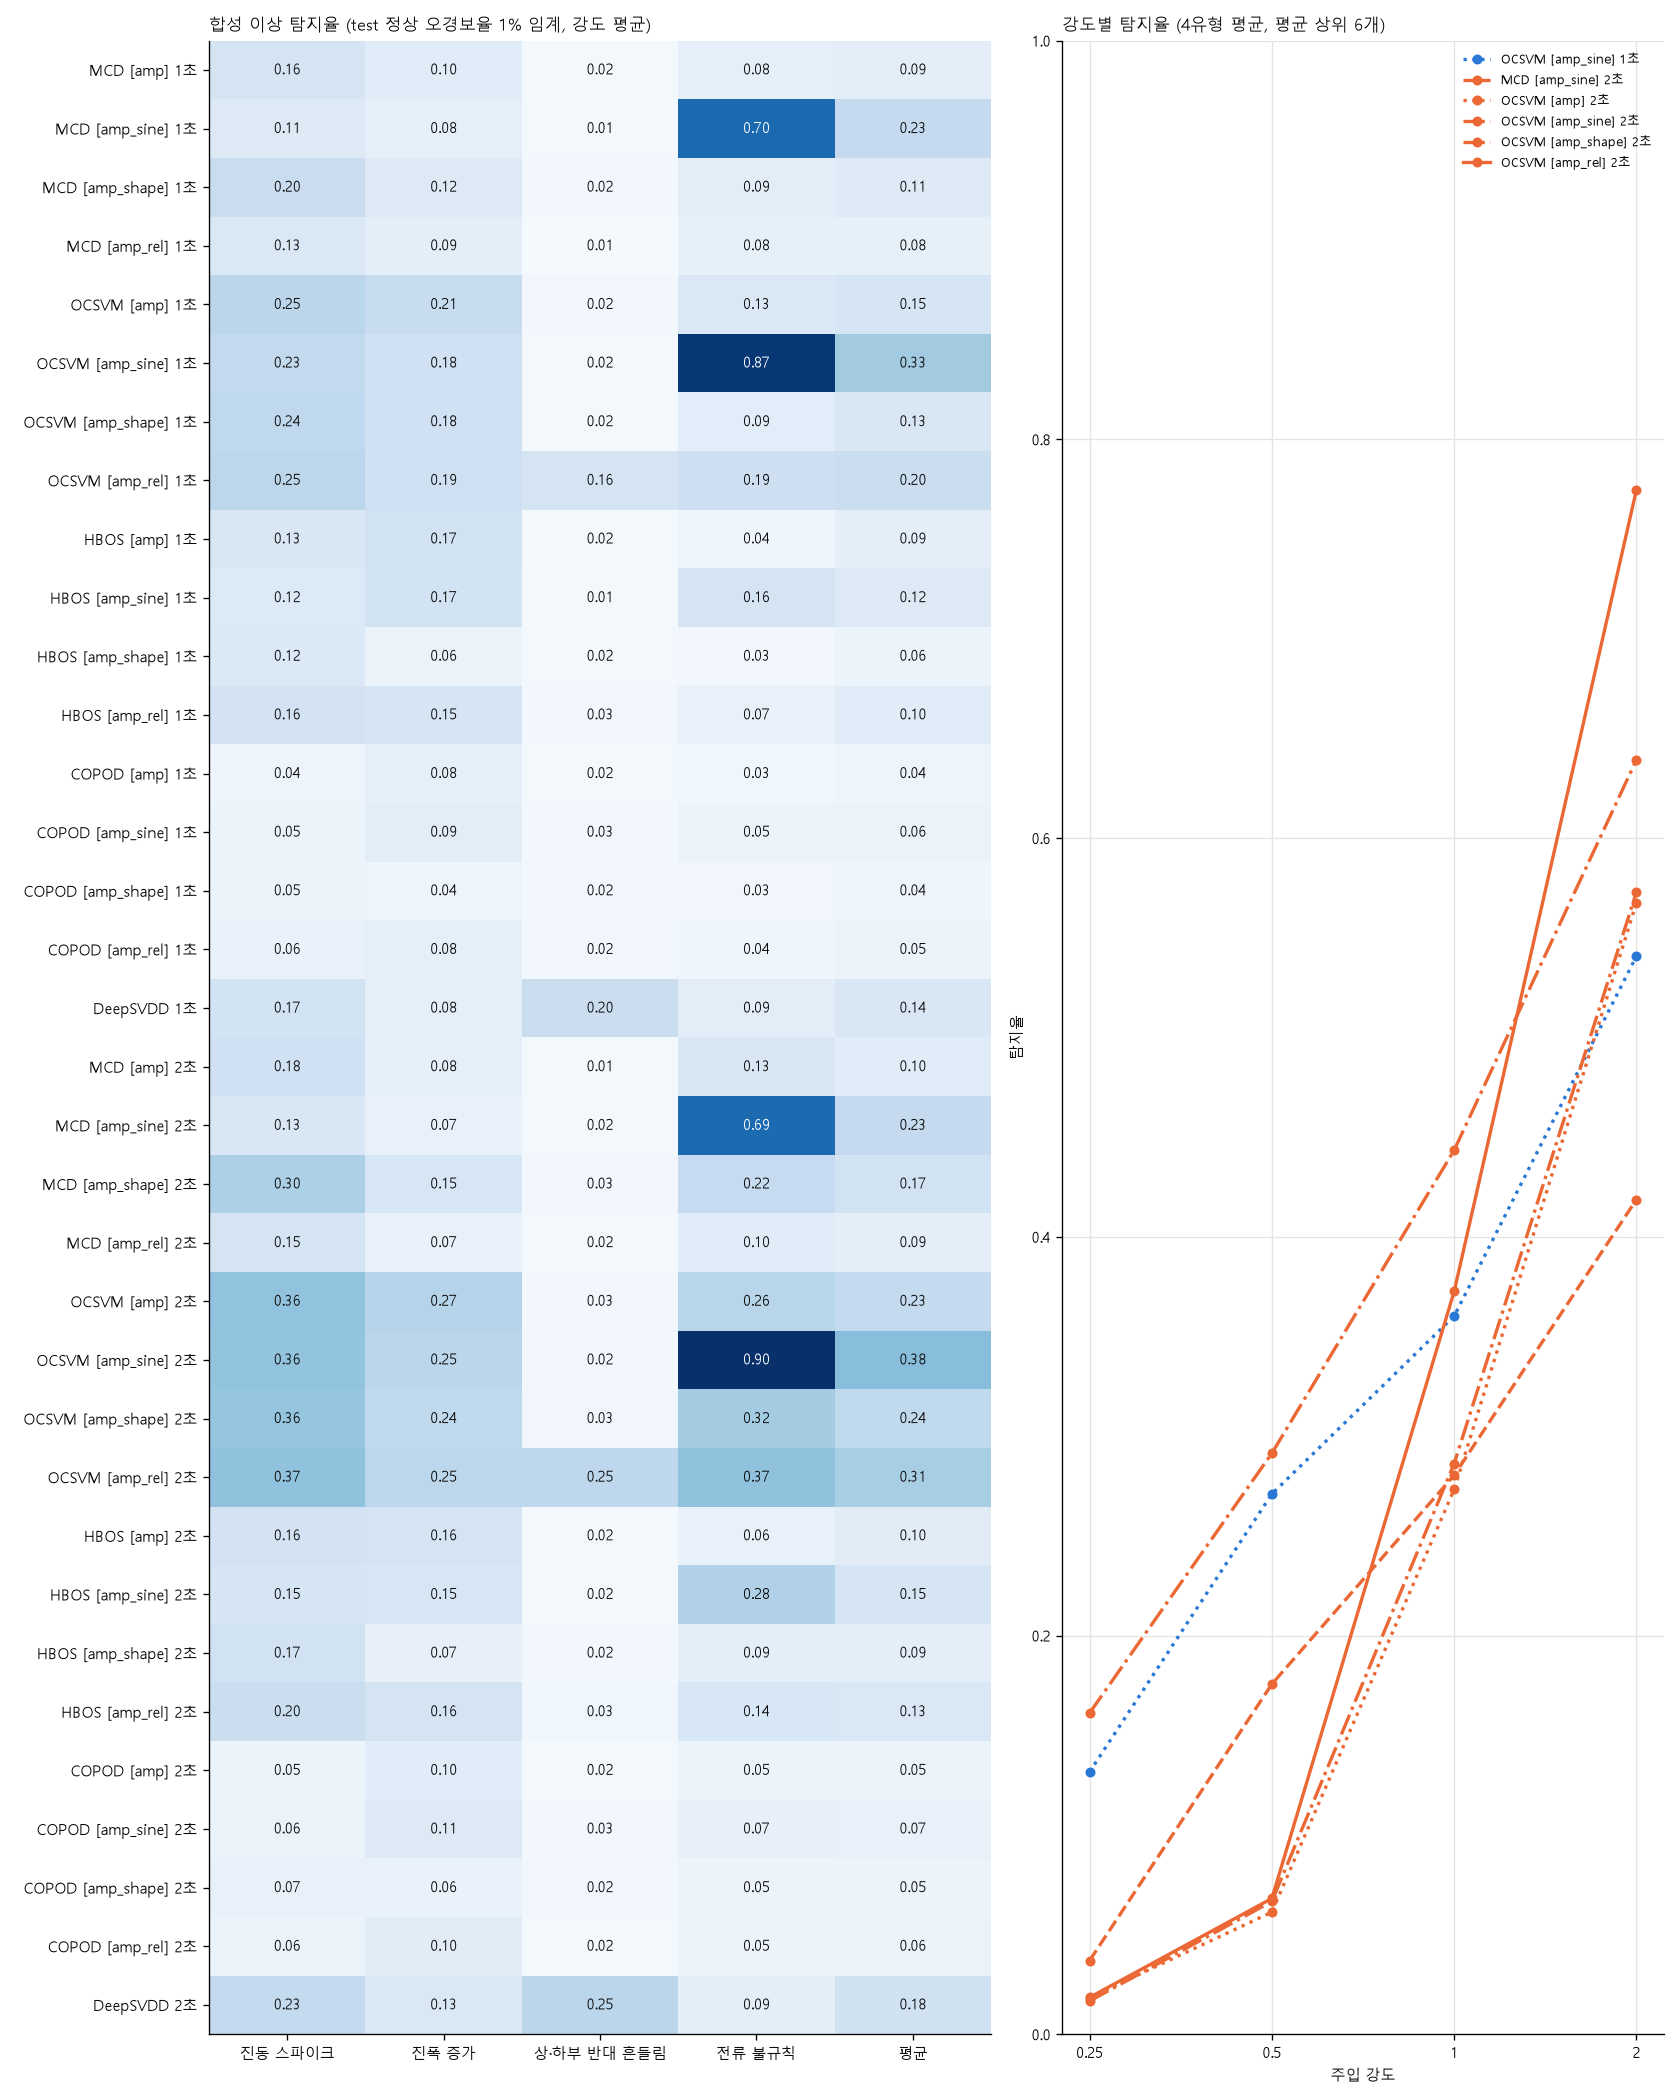

In [8]:
B.plot_injection(cv, FIG); display(Image(FIG / "injection.png"))

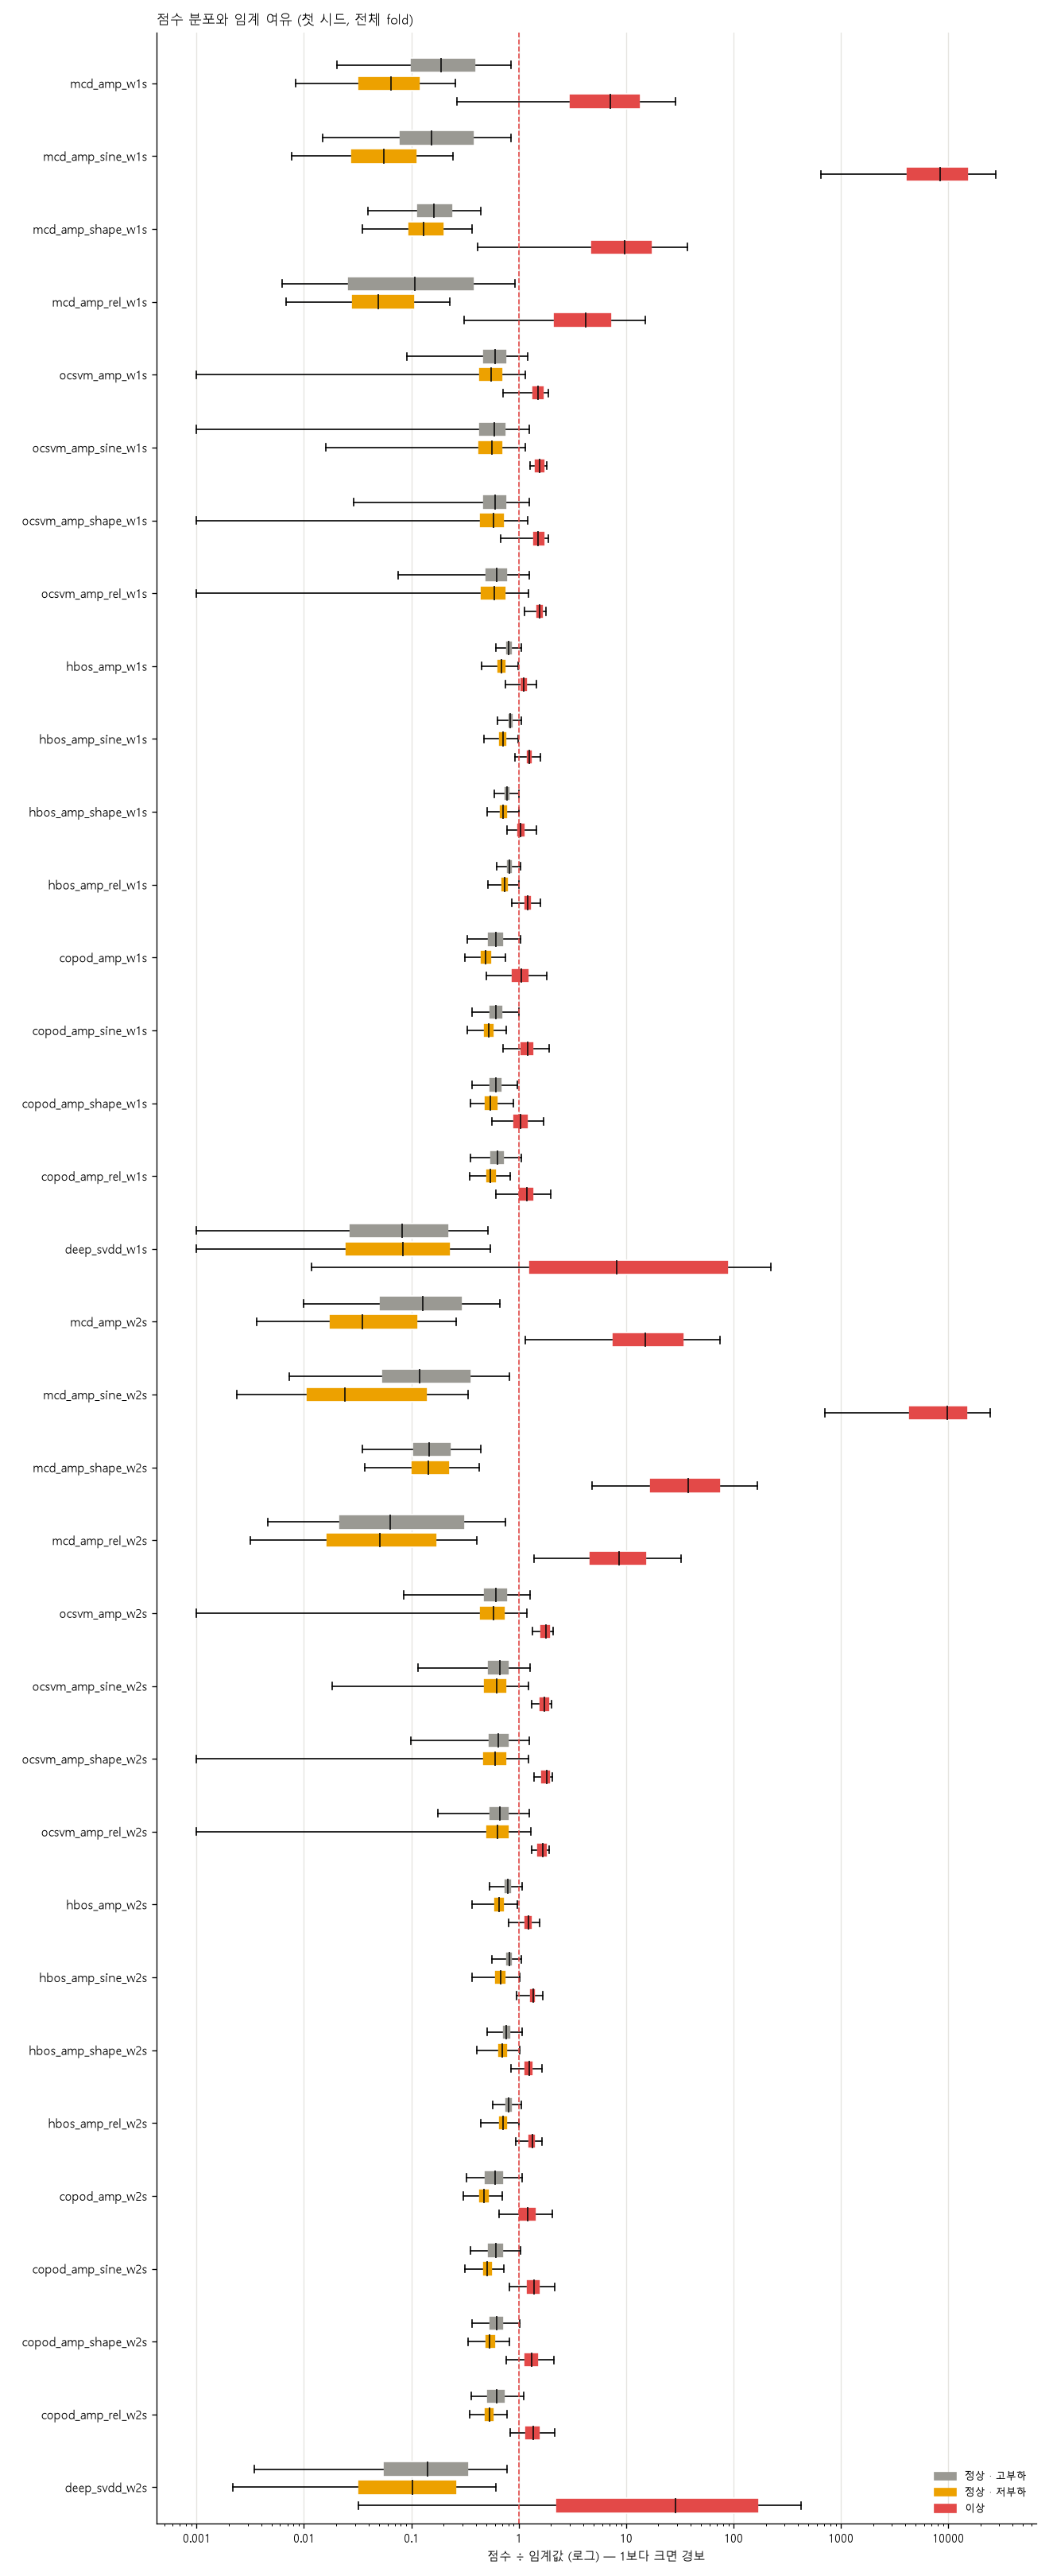

In [9]:
B.plot_score_margin(sc, FIG); display(Image(FIG / "score_margin.png"))

## 5. 오류 사례 (첫 시드)

FP = 초과 윈도우가 1개라도 있는 정상 세그먼트, FN = 한 번도 초과하지 않은 이상 세그먼트. 31 오류분석 노트북의 입력으로 쓴다.

In [10]:
fp = err[err["type"] == "FP"].groupby(["model_id", "state"]).size().unstack(fill_value=0)
fn = err[err["type"] == "FN"].groupby(["model_id", "seg_uid"]).size().unstack(fill_value=0) if (err["type"] == "FN").any() else pd.DataFrame()
display(fp.rename(columns=lambda c: f"FP 세그먼트({c})"))
fn

state,FP 세그먼트(고부하),FP 세그먼트(저부하)
model_id,,
copod_amp_rel_w1s,27,3
copod_amp_rel_w2s,12,0
copod_amp_shape_w1s,16,16
copod_amp_shape_w2s,14,3
copod_amp_sine_w1s,20,2
copod_amp_sine_w2s,11,0
copod_amp_w1s,26,2
copod_amp_w2s,12,0
deep_svdd_w1s,44,37


seg_uid,outlier_19,outlier_3,outlier_4
model_id,,,
copod_amp_rel_w1s,5,0,0
copod_amp_shape_w1s,5,0,2
copod_amp_sine_w1s,4,0,0
copod_amp_w1s,5,1,0
deep_svdd_w1s,1,0,0
hbos_amp_shape_w1s,5,0,0
hbos_amp_w1s,3,0,0


## 6. 해석

발견 → 시사점 → 활용 아이디어는 `reports/26_model_distribution_JIW.md`에 정리했다.